In [11]:
# Libs
from time import gmtime, strftime
import xarray as xr
import numpy as np

# Locals
from oggm import utils, workflow, tasks, DEFAULT_BASE_URL
import oggm.cfg as cfg
from oggm.shop import gcm_climate

In [12]:
import xarray as xr

with xr.open_dataset('/home/usman/Music/GeeMap/Results/15_GCM_projections.nc') as ds:
    ds_merged = ds


In [13]:
ds_total_volume = ds_merged['area'].sum(dim='rgi_id',  # over which dimension the sum should be taken, here we want to sum up over all glacier ids
                                          skipna=True,  # ignore nan values
                                          # important, we need values for every glacier (here 2) to do the sum
                                          # if some have NaN, the sum should also be NaN (if you don't set min_count, the sum will be 0, which is bad)
                                          min_count=len(ds_merged.rgi_id), 
                                          keep_attrs=True)  # keep the variable descriptions   


In [14]:
ds_total_volume

<xarray.DataArray 'area' (SCENARIO: 3, GCM: 5, time: 87)> Size: 10kB
array([[[2.66197057e+08, 2.66154407e+08, 2.65862835e+08, ...,
         2.26164680e+08, 2.25848716e+08, 2.25137578e+08],
        [2.66197057e+08, 2.66300712e+08, 2.66304898e+08, ...,
         2.33616477e+08, 2.33055366e+08, 2.32497543e+08],
        [2.66197057e+08, 2.65992014e+08, 2.65912104e+08, ...,
         2.44388243e+08, 2.44215909e+08, 2.43466567e+08],
        [2.66197057e+08, 2.66091641e+08, 2.66090039e+08, ...,
         2.40435696e+08, 2.40617604e+08, 2.40264386e+08],
        [2.66197057e+08, 2.66092141e+08, 2.66185088e+08, ...,
         1.96714465e+08, 1.96129170e+08, 1.93436027e+08]],

       [[2.66197057e+08, 2.66280307e+08, 2.66359113e+08, ...,
         2.01516584e+08, 2.00581356e+08, 2.00802236e+08],
        [2.66197057e+08, 2.66126485e+08, 2.65981888e+08, ...,
         2.03429749e+08, 2.01184315e+08, 1.96509520e+08],
        [2.66197057e+08, 2.65993729e+08, 2.66006685e+08, ...,
         2.06186047e+08, 2.04312109e+08, 2.02242975e+08],
        [2.66197057e+08, 2.66235326e+08, 2.66060026e+08, ...,
         2.18833219e+08, 2.16614847e+08, 2.15483217e+08],
        [2.66197057e+08, 2.66027187e+08, 2.65887647e+08, ...,
         1.22099918e+08, 1.20575507e+08, 1.17190681e+08]],

       [[2.66197057e+08, 2.66307173e+08, 2.66250592e+08, ...,
         1.93501016e+08, 1.91830827e+08, 1.90289150e+08],
        [2.66197057e+08, 2.66252020e+08, 2.66092777e+08, ...,
         1.53262600e+08, 1.51855310e+08, 1.46492370e+08],
        [2.66197057e+08, 2.66186536e+08, 2.66272400e+08, ...,
         1.91603891e+08, 1.89252201e+08, 1.81042958e+08],
        [2.66197057e+08, 2.66161784e+08, 2.66050980e+08, ...,
         1.99046661e+08, 1.96777418e+08, 1.94550539e+08],
        [2.66197057e+08, 2.66112402e+08, 2.66050302e+08, ...,
         7.97097837e+07, 6.93861441e+07, 7.25737716e+07]]],
      shape=(3, 5, 87))
Coordinates:
  * time            (time) float64 696B 2.015e+03 2.016e+03 ... 2.101e+03
    hydro_year      (time) int64 696B ...
    hydro_month     (time) int64 696B ...
    calendar_year   (time) int64 696B ...
    calendar_month  (time) int64 696B ...
  * GCM             (GCM) <U22 440B 'gfdl-esm4_r1i1p1f1' ... 'ukesm1-0-ll_r1i...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Attributes:
    description:  Total glacier area
    unit:         m 2

In [15]:
ds_total_volume_median = ds_total_volume.median(dim='GCM',  # over which dimension the median should be calculated
                                            skipna=True,  # ignore nan values
                                            keep_attrs=True)  # keep all variable descriptions
ds_total_volume_median

<xarray.DataArray 'area' (SCENARIO: 3, time: 87)> Size: 2kB
array([[2.66197057e+08, 2.66092141e+08, 2.66090039e+08, 2.66032072e+08,
        2.65698751e+08, 2.65720602e+08, 2.65631606e+08, 2.65638450e+08,
        2.65457490e+08, 2.65358278e+08, 2.65156290e+08, 2.64982298e+08,
        2.64676990e+08, 2.64652812e+08, 2.64386747e+08, 2.64234024e+08,
        2.63965049e+08, 2.63623637e+08, 2.63307070e+08, 2.63018434e+08,
        2.62498067e+08, 2.62125426e+08, 2.61942898e+08, 2.61581478e+08,
        2.61249695e+08, 2.60868374e+08, 2.60516473e+08, 2.60037434e+08,
        2.59847697e+08, 2.59763757e+08, 2.59327733e+08, 2.58713881e+08,
        2.58241588e+08, 2.57714191e+08, 2.57468918e+08, 2.57190130e+08,
        2.56815400e+08, 2.56003659e+08, 2.55747269e+08, 2.55608638e+08,
        2.55273704e+08, 2.54937909e+08, 2.54358939e+08, 2.54042622e+08,
        2.53623283e+08, 2.52936478e+08, 2.52576831e+08, 2.52279177e+08,
        2.51664513e+08, 2.51513160e+08, 2.50960538e+08, 2.49819464e+08,
        2.49267220e+08, 2.49115262e+08, 2.48588749e+08, 2.48431862e+08,
        2.48116958e+08, 2.47783833e+08, 2.47599073e+08, 2.47569068e+08,
        2.47212328e+08, 2.46590310e+08, 2.46451385e+08, 2.46121712e+08,
        2.45577956e+08, 2.44886210e+08, 2.44428089e+08, 2.43866142e+08,
        2.43384650e+08, 2.42929362e+08, 2.42188271e+08, 2.41682410e+08,
        2.40869040e+08, 2.40177141e+08, 2.39977309e+08, 2.39542826e+08,
        2.39079601e+08, 2.38254911e+08, 2.37828267e+08, 2.36970833e+08,
...
        2.65493350e+08, 2.65387838e+08, 2.65150119e+08, 2.64747409e+08,
        2.64485109e+08, 2.64183228e+08, 2.63884810e+08, 2.63678687e+08,
        2.63752040e+08, 2.63386359e+08, 2.62966138e+08, 2.62502973e+08,
        2.62196059e+08, 2.61923844e+08, 2.61661231e+08, 2.61205903e+08,
        2.60886109e+08, 2.60441580e+08, 2.59625855e+08, 2.58996656e+08,
        2.58452239e+08, 2.57824801e+08, 2.57299018e+08, 2.56655036e+08,
        2.56449981e+08, 2.56023848e+08, 2.55052515e+08, 2.54591631e+08,
        2.53958058e+08, 2.53282688e+08, 2.52245295e+08, 2.51550322e+08,
        2.50688888e+08, 2.49850182e+08, 2.49035545e+08, 2.48189870e+08,
        2.47224551e+08, 2.46531041e+08, 2.45459371e+08, 2.44099318e+08,
        2.42953008e+08, 2.41041405e+08, 2.40238523e+08, 2.39377746e+08,
        2.38360821e+08, 2.37097469e+08, 2.35904142e+08, 2.34849697e+08,
        2.33663797e+08, 2.32645891e+08, 2.32159943e+08, 2.31979309e+08,
        2.31407167e+08, 2.29979209e+08, 2.28856286e+08, 2.26732596e+08,
        2.25203426e+08, 2.23526314e+08, 2.21535310e+08, 2.20408956e+08,
        2.18318604e+08, 2.17396548e+08, 2.15823241e+08, 2.13488827e+08,
        2.12421192e+08, 2.10641045e+08, 2.08560659e+08, 2.07418772e+08,
        2.06008149e+08, 2.04376171e+08, 2.02601120e+08, 1.99379397e+08,
        1.98084073e+08, 1.96845036e+08, 1.94422037e+08, 1.92583201e+08,
        1.91603891e+08, 1.89252201e+08, 1.81042958e+08]])
Coordinates:
  * time            (time) float64 696B 2.015e+03 2.016e+03 ... 2.101e+03
    hydro_year      (time) int64 696B ...
    hydro_month     (time) int64 696B ...
    calendar_year   (time) int64 696B ...
    calendar_month  (time) int64 696B ...
  * SCENARIO        (SCENARIO) <U6 72B 'ssp126' 'ssp370' 'ssp585'
Attributes:
    description:  Total glacier area
    unit:         m 2

In [16]:
import matplotlib.pyplot as plt

In [17]:
# estimate the minimum volume for each time step and scenario over the GCMs
ds_total_volume_min = ds_total_volume.min(dim='GCM', keep_attrs=True,skipna=True)
# estimate the 25th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p25 = ds_total_volume.quantile(0.25, dim='GCM', keep_attrs=True,skipna=True)
# estimate the 50th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p50 = ds_total_volume.quantile(0.5, dim='GCM', keep_attrs=True,skipna=True)
# this is the same as the median -> Let's check
np.testing.assert_allclose(ds_total_volume_median,ds_total_volume_p50)
# estimate the 75th percentile volume for each time step and scenario over the GCMs
ds_total_volume_p75 = ds_total_volume.quantile(0.75, dim='GCM', keep_attrs=True,skipna=True)
# estimate the maximum volume for each time step and scenario over the GCMs
ds_total_volume_max = ds_total_volume.max(dim='GCM', keep_attrs=True,skipna=True)

# Think twice if it is appropriate to compute a mean/std over your GCM sample, is it Gaussian distributed?
# Otherwise use instead median and percentiles or total range
ds_total_volume_mean = ds_total_volume.mean(dim='GCM', keep_attrs=True,
                                            skipna=True)
ds_total_volume_std = ds_total_volume.std(dim='GCM', keep_attrs=True,
                                            skipna=True)

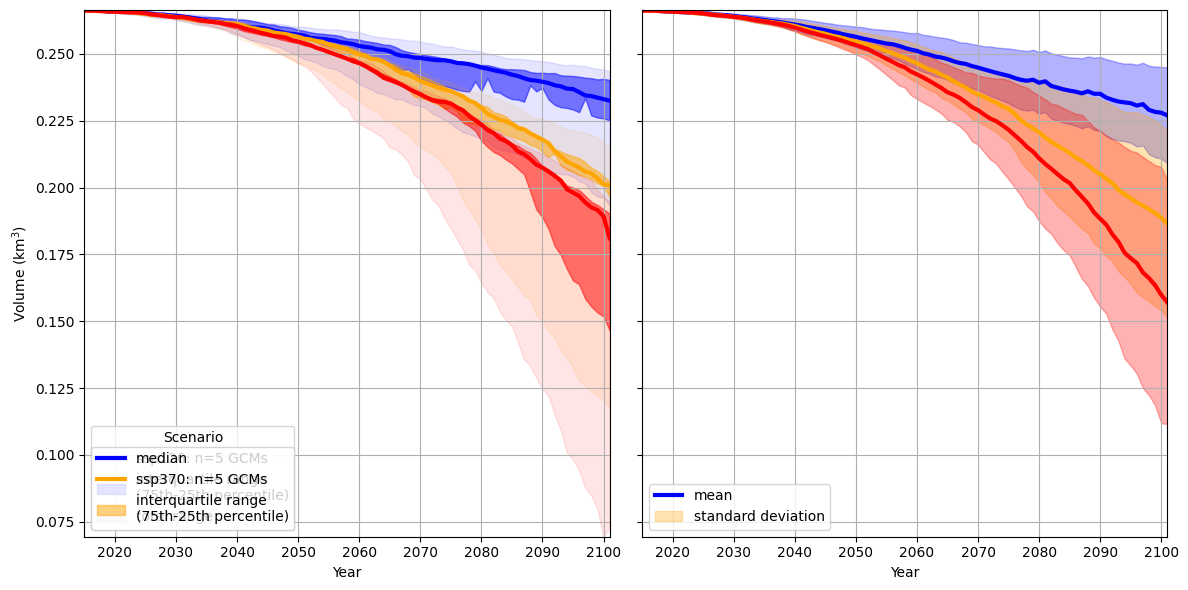

In [18]:
import matplotlib.pyplot as plt

# Define color mapping for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)  # Share y-axis between subplots

# Plot the data for each scenario
for scenario in color_dict.keys():
    # Get the number of GCMs per scenario
    n = len(ds_total_volume.sel(SCENARIO=scenario).dropna(dim='GCM').GCM)
    
    # Plot median data with interquartile and total range
    axs[0].plot(ds_total_volume_median.time,
                ds_total_volume_median.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                label=f'{scenario}: n={n} GCMs',
                color=color_dict[scenario], lw=3)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_p25.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_p75.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.5,
                        label='interquartile range\n(75th-25th percentile)')
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_min.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_max.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.1,
                        label='total range')

# Plot mean and standard deviation
for scenario in color_dict.keys():
    axs[1].plot(ds_total_volume_mean.time,
                ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                color=color_dict[scenario], label='mean', lw=3)
    axs[1].fill_between(ds_total_volume_mean.time,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 - ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 + ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        alpha=0.3, color=color_dict[scenario], label='standard deviation')

# Adjust axis limits dynamically to fit the data perfectly
for ax in axs:
    # Set x-axis limits based on data time range
    ax.set_xlim([ds_total_volume_mean.time.min().values, ds_total_volume_mean.time.max().values])
    
    # Set y-axis limits based on minimum and maximum values across all scenarios
    y_min = ds_total_volume_min.min().values / 1e9  # Convert to km³
    y_max = ds_total_volume_max.max().values / 1e9  # Convert to km³
    ax.set_ylim([y_min, y_max])
    
    # Get handles and labels for the legends
    handles, labels = ax.get_legend_handles_labels()
    if ax == axs[0]:
        # First legend: Colors and SSPs
        leg1 = ax.legend(handles[:3], labels[:3], title='Scenario')
        ax.set_ylabel(r'Volume (km$^3$)')
        # Second legend: Statistical estimates
        ax.legend([handles[0], handles[3], handles[4]],
                  ['median', labels[3], labels[4]], loc='lower left')
        ax.add_artist(leg1)  # Allow two legends
    else:
        # Second plot: Mean and standard deviation
        ax.legend(handles[::3], labels[::3], loc='lower left')
    
    # Set common labels and grid
    ax.set_xlabel('Year')
    ax.grid()

# Show the plot
plt.tight_layout()
plt.savefig('/home/usman/Music/GeeMap/Results/Volume/Mean_GCM_projection.png', dpi=500, bbox_inches='tight')
plt.show()


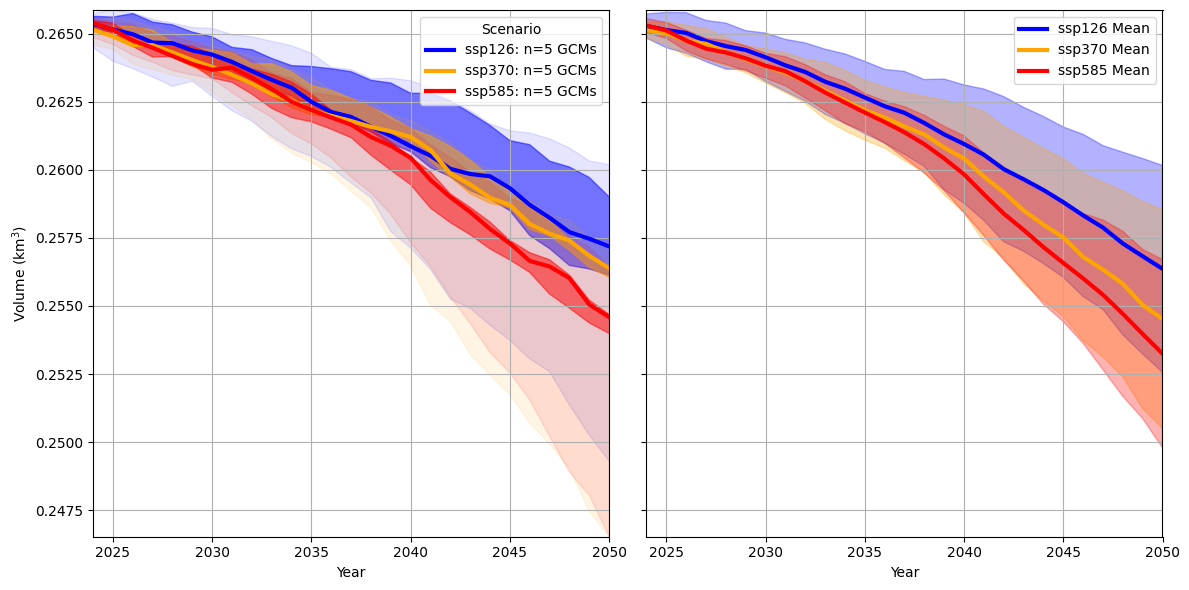

In [19]:
import matplotlib.pyplot as plt

# Define color mapping for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Create subplots with adequate size
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)  # Share y-axis between subplots

# Plot the data for each scenario
for scenario in color_dict.keys():
    # Get the number of GCMs per scenario
    n = len(ds_total_volume.sel(SCENARIO=scenario).dropna(dim='GCM').GCM)
    
    # Plot median data with interquartile and total range
    axs[0].plot(ds_total_volume_median.time,
                ds_total_volume_median.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                label=f'{scenario}: n={n} GCMs',
                color=color_dict[scenario], lw=3)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_p25.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_p75.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.5)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_min.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_max.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.1)

# Plot mean and standard deviation
for scenario in color_dict.keys():
    axs[1].plot(ds_total_volume_mean.time,
                ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                color=color_dict[scenario], label=f'{scenario} Mean', lw=3)
    axs[1].fill_between(ds_total_volume_mean.time,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 - ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 + ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        alpha=0.3, color=color_dict[scenario])

# Set precise axis limits for the projection period 2024–2050
for ax in axs:
    # Set x-axis limits
    ax.set_xlim([2024, 2050])

    # Calculate precise y-axis limits based on data
    y_min = min(
        ds_total_volume_min.sel(time=slice(2024, 2050)).min().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2024, 2050)).min().values / 1e9
    )
    y_max = max(
        ds_total_volume_max.sel(time=slice(2024, 2050)).max().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2024, 2050)).max().values / 1e9
    )
    ax.set_ylim([y_min, y_max])
    
    # Configure legends and labels
    handles, labels = ax.get_legend_handles_labels()
    if ax == axs[0]:
        # Add legend for the first subplot
        ax.legend(title='Scenario', loc='upper right')
        ax.set_ylabel(r'Volume (km$^3$)')
    else:
        ax.legend(loc='upper right')
    
    # Set common labels and grid
    ax.set_xlabel('Year')
    ax.grid()

# Save and display the plot
plt.tight_layout()
plt.savefig('/home/usman/Music/GeeMap/Results/Volume/Mean_GCM_projection_2024_2050_fitted.png', dpi=500, bbox_inches='tight')
plt.show()


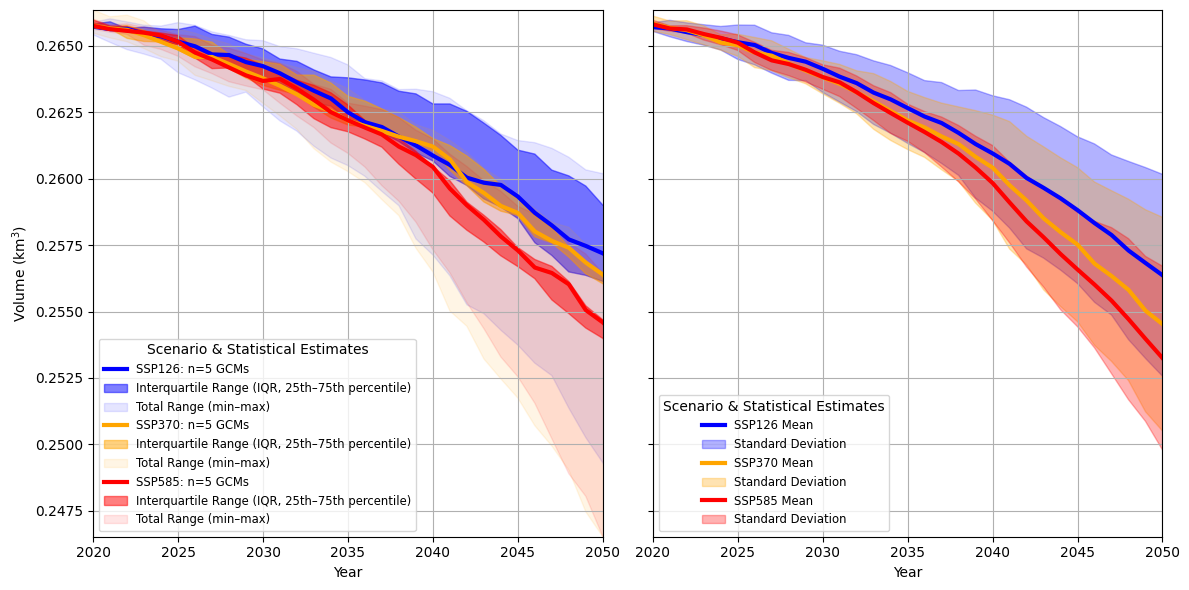

In [20]:
import matplotlib.pyplot as plt

# Define color mapping for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Create subplots with adequate size
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)  # Share y-axis between subplots

# Plot the data for each scenario
for scenario in color_dict.keys():
    # Get the number of GCMs per scenario
    n = len(ds_total_volume.sel(SCENARIO=scenario).dropna(dim='GCM').GCM)
    
    # Plot median data with interquartile and total range
    axs[0].plot(ds_total_volume_median.time,
                ds_total_volume_median.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                label=f'{scenario.upper()}: n={n} GCMs',
                color=color_dict[scenario], lw=3)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_p25.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_p75.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.5,
                        label='Interquartile Range (IQR, 25th–75th percentile)')
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_min.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_max.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.1,
                        label='Total Range (min–max)')

# Plot mean and standard deviation
for scenario in color_dict.keys():
    axs[1].plot(ds_total_volume_mean.time,
                ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                color=color_dict[scenario], label=f'{scenario.upper()} Mean', lw=3)
    axs[1].fill_between(ds_total_volume_mean.time,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 - ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 + ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        alpha=0.3, color=color_dict[scenario],
                        label='Standard Deviation')

# Set precise axis limits for the projection period 2024–2050
for ax in axs:
    # Set x-axis limits
    ax.set_xlim([2020, 2050])

    # Calculate precise y-axis limits based on data
    y_min = min(
        ds_total_volume_min.sel(time=slice(2020, 2050)).min().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2020, 2050)).min().values / 1e9
    )
    y_max = max(
        ds_total_volume_max.sel(time=slice(2020, 2050)).max().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2020, 2050)).max().values / 1e9
    )
    ax.set_ylim([y_min, y_max])
    
    # Configure legends and labels
    if ax == axs[0]:
        # Add legend for the first subplot
        ax.legend(title='Scenario & Statistical Estimates', loc='lower left', fontsize='small')
        ax.set_ylabel(r'Volume (km$^3$)')
    else:
        ax.legend(title='Scenario & Statistical Estimates', loc='lower left', fontsize='small')
    
    # Set common labels and grid
    ax.set_xlabel('Year')
    ax.grid()

# Save and display the plot
plt.tight_layout()
plt.savefig('/home/usman/Music/GeeMap/Results/Volume/Mean_GCM_projection_2020_2050_fitted_001.png', dpi=500, bbox_inches='tight')
plt.show()


In [21]:
# Merge DataFrames on correct keys, avoiding duplicate columns
merge_keys = ['time', 'SCENARIO']  # Adjust keys if needed

# Drop duplicate or unnecessary columns before merging
columns_to_keep = ['time', 'SCENARIO', 'median_volume_km3', 'mean_volume_km3', 'min_volume_km3', 'max_volume_km3', 
                   'p25_volume_km3', 'p75_volume_km3', 'std_volume_km3']

# Ensure no duplicate columns cause merge conflicts
df_median = df_median.loc[:, ~df_median.columns.duplicated()]
df_mean = df_mean.loc[:, ~df_mean.columns.duplicated()]
df_min = df_min.loc[:, ~df_min.columns.duplicated()]
df_max = df_max.loc[:, ~df_max.columns.duplicated()]
df_p25 = df_p25.loc[:, ~df_p25.columns.duplicated()]
df_p75 = df_p75.loc[:, ~df_p75.columns.duplicated()]
df_std = df_std.loc[:, ~df_std.columns.duplicated()]

# Start merging
df_combined = pd.merge(df_median, df_mean, on=merge_keys, how='outer', suffixes=('', '_mean'))
df_combined = pd.merge(df_combined, df_min, on=merge_keys, how='outer', suffixes=('', '_min'))
df_combined = pd.merge(df_combined, df_max, on=merge_keys, how='outer', suffixes=('', '_max'))
df_combined = pd.merge(df_combined, df_p25, on=merge_keys, how='outer', suffixes=('', '_p25'))
df_combined = pd.merge(df_combined, df_p75, on=merge_keys, how='outer', suffixes=('', '_p75'))
df_combined = pd.merge(df_combined, df_std, on=merge_keys, how='outer', suffixes=('', '_std'))

# Save the combined DataFrame to an Excel file
excel_output_path = '/home/usman/Music/GeeMap/Results/Volume/Mean_GCM_projection_data_2020_2050.xlsx'
df_combined.to_excel(excel_output_path, index=False)

# Print Excel save confirmation
print(f"Final data saved to: {excel_output_path}")


NameError: name 'df_median' is not defined

In [ ]:
import matplotlib.pyplot as plt

# Define color mapping for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Create subplots with adequate size
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)  # Share y-axis between subplots

# Plot the data for each scenario
for scenario in color_dict.keys():
    # Get the number of GCMs per scenario
    n = len(ds_total_volume.sel(SCENARIO=scenario).dropna(dim='GCM').GCM)
    
    # Plot median data with interquartile and total range
    axs[0].plot(ds_total_volume_median.time,
                ds_total_volume_median.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                label=f'{scenario.upper()}: n={n} GCMs',
                color=color_dict[scenario], lw=3)
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_p25.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_p75.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.5,
                        label='Interquartile Range (IQR, 25th–75th percentile)')
    axs[0].fill_between(ds_total_volume_median.time,
                        ds_total_volume_min.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_max.sel(SCENARIO=scenario) / 1e9,
                        color=color_dict[scenario], alpha=0.1,
                        label='Total Range (min–max)')

# Plot mean and standard deviation
for scenario in color_dict.keys():
    axs[1].plot(ds_total_volume_mean.time,
                ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9,  # Convert m³ -> km³
                color=color_dict[scenario], label=f'{scenario.upper()} Mean', lw=3)
    axs[1].fill_between(ds_total_volume_mean.time,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 - ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        ds_total_volume_mean.sel(SCENARIO=scenario) / 1e9 + ds_total_volume_std.sel(SCENARIO=scenario) / 1e9,
                        alpha=0.3, color=color_dict[scenario],
                        label='Standard Deviation')

# Set precise axis limits for the projection period 2024–2050
for ax in axs:
    # Set x-axis limits
    ax.set_xlim([2020, 2100])

    # Calculate precise y-axis limits based on data
    y_min = min(
        ds_total_volume_min.sel(time=slice(2020, 2100)).min().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2020, 2050)).min().values / 1e9
    )
    y_max = max(
        ds_total_volume_max.sel(time=slice(2020, 2100)).max().values / 1e9,
        ds_total_volume_mean.sel(time=slice(2020, 2100)).max().values / 1e9
    )
    ax.set_ylim([y_min, y_max])
    
    # Configure legends and labels
    if ax == axs[0]:
        # Add legend for the first subplot
        ax.legend(title='Scenario & Statistical Estimates', loc='lower left', fontsize='small')
        ax.set_ylabel(r'Volume (km$^3$)')
    else:
        ax.legend(title='Scenario & Statistical Estimates', loc='lower left', fontsize='small')
    
    # Set common labels and grid
    ax.set_xlabel('Year')
    ax.grid()

# Save and display the plot
plt.tight_layout()
plt.savefig('/home/usman/Music/GeeMap/Results/Volume/Mean_GCM_projection_2020_2100_fitted_001.png', dpi=500, bbox_inches='tight')
plt.show()


In [ ]:
import seaborn as sns
import pandas as pd

# Convert xarray Dataset to DataFrame
pd_total_volume = ds_total_volume.to_dataframe('volume_m3').reset_index()

# Convert volume from m^3 to km^3 and filter the time range from 2020 to 2050
pd_total_volume['volume_km3'] = pd_total_volume['volume_m3'] / 1e9  # Convert to km^3
pd_total_volume_filtered = pd_total_volume[(pd_total_volume['time'] >= 2020) & (pd_total_volume['time'] <= 2100)]

# Plot with Seaborn
sns.lineplot(x='time', y='volume_km3',
             hue='SCENARIO',  # Different colors for scenarios
             estimator='median',  # Use the median
             data=pd_total_volume_filtered,  # Filtered data
             lw=2,  # Increase the linewidth
             palette=color_dict,  # Same colors as before
             errorbar=('pi', 90)  # 90th percentile range
            );

# Add labels and grid
plt.xlabel('Year')
plt.ylabel(r'Volume (km$^3$)')
plt.title('Glacier Volume Projections (2020-2050)')
plt.grid(True)
plt.tight_layout()

plt.savefig('/home/usman/Music/GeeMap/Results/Volume/projection_2020_2100.png', dpi=500, bbox_inches='tight')
plt.show()
